In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [3]:
class AgentState(TypedDict):
    number1: int
    number2: int
    operation: str
    result: int

In [4]:
def adder(state: AgentState) -> AgentState:
    """This node adds two numbers"""
    state["result"] = state["number1"] + state["number2"]
    return state

def substract(state: AgentState) -> AgentState:
    """This node substracts two numbers"""
    state["result"] = state["number1"] - state["number2"]
    return state

def decide_next_node(state: AgentState) -> str:
    """This node will decide the next node of the graph"""
    if state["operation"] == "+":
        return "add_op"
    if state["operation"] == "-":
        return "substract_op"


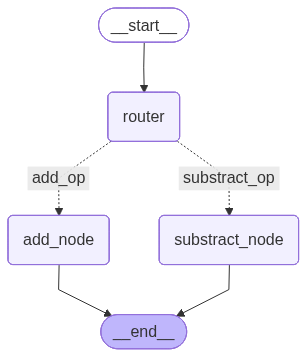

In [6]:
graph = StateGraph(AgentState)
graph.add_node("add_node", adder)
graph.add_node("substract_node", substract)
graph.add_node("router", lambda state: state)

graph.add_edge(START, "router")
graph.add_conditional_edges(
    "router",
    decide_next_node,
    {
        "add_op": "add_node",
        "substract_op": "substract_node"
    }
)
graph.add_edge("add_node", END)
graph.add_edge("substract_node", END)

bot = graph.compile()
bot

In [13]:
input_state = {
    "number1": 10,
    "number2": 4,
    "operation": "+",
}

final_response = bot.invoke(input_state)
final_response

{'number1': 10, 'number2': 4, 'operation': '+', 'result': 14}